✅ Successfully set path to: c:\Users\kpram\OneDrive\Documents\JAN - APR '26\CS 328 DB\Career Track\CareerTrack-PMS\Module_A
✅ Successfully reloaded BPlusTree and BruteForceDB from disk!
✅ Successfully set path to: c:\Users\kpram\OneDrive\Documents\JAN - APR '26\CS 328 DB\Career Track\CareerTrack-PMS\Module_A


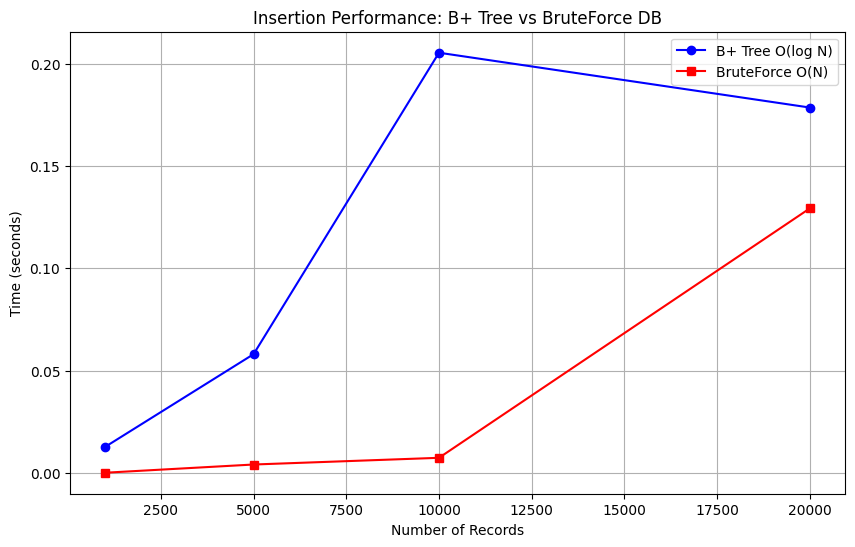

In [4]:
import sys
import os
import time
import random
import matplotlib.pyplot as plt
import importlib  # <--- The magic bullet

# The ultimate path fix: figure out exactly where we are
current_dir = os.getcwd()

if current_dir.endswith('database'):
    module_a_dir = os.path.dirname(current_dir)
elif current_dir.endswith('Module_A'):
    module_a_dir = current_dir
else:
    module_a_dir = os.path.join(current_dir, 'Module_A')

# Inject it into Python's brain
if module_a_dir not in sys.path:
    sys.path.insert(0, module_a_dir)

print(f"✅ Successfully set path to: {module_a_dir}")

# 1. Import the modules themselves
import database.bplustree
import database.bruteforce

# 2. FORCE Python to re-read the files from disk!
importlib.reload(database.bplustree)
importlib.reload(database.bruteforce)

# 3. Now bind the specific classes
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB

print("✅ Successfully reloaded BPlusTree and BruteForceDB from disk!")
# The ultimate path fix: figure out exactly where we are
current_dir = os.getcwd()

if current_dir.endswith('database'):
    # We are one level too deep, go up to Module_A!
    module_a_dir = os.path.dirname(current_dir)
elif current_dir.endswith('Module_A'):
    # We are in the exact right spot
    module_a_dir = current_dir
else:
    # We are in the root CareerTrack-PMS folder, go down to Module_A!
    module_a_dir = os.path.join(current_dir, 'Module_A')

# Inject it into Python's brain
if module_a_dir not in sys.path:
    sys.path.insert(0, module_a_dir)

print(f"✅ Successfully set path to: {module_a_dir}")

# Now the imports WILL work
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB

def benchmark_insertions(sizes):
    bplus_times = []
    brute_times = []
    
    for size in sizes:
        bpt = BPlusTree(order=4)
        bf = BruteForceDB()
        
        keys = random.sample(range(1, size * 10), size)
        
        # Benchmark B+ Tree
        start = time.time()
        for key in keys:
            bpt.insert(key, f"Val_{key}")
        bplus_times.append(time.time() - start)
        
        # Benchmark Brute Force
        start = time.time()
        for key in keys:
            bf.insert(key, f"Val_{key}")
        brute_times.append(time.time() - start)
        
    return bplus_times, brute_times

# Run the benchmark
dataset_sizes = [1000, 5000, 10000, 20000]
bplus_results, brute_results = benchmark_insertions(dataset_sizes)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(dataset_sizes, bplus_results, marker='o', label='B+ Tree O(log N)', color='blue')
plt.plot(dataset_sizes, brute_results, marker='s', label='BruteForce O(N)', color='red')
plt.title('Insertion Performance: B+ Tree vs BruteForce DB')
plt.xlabel('Number of Records')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

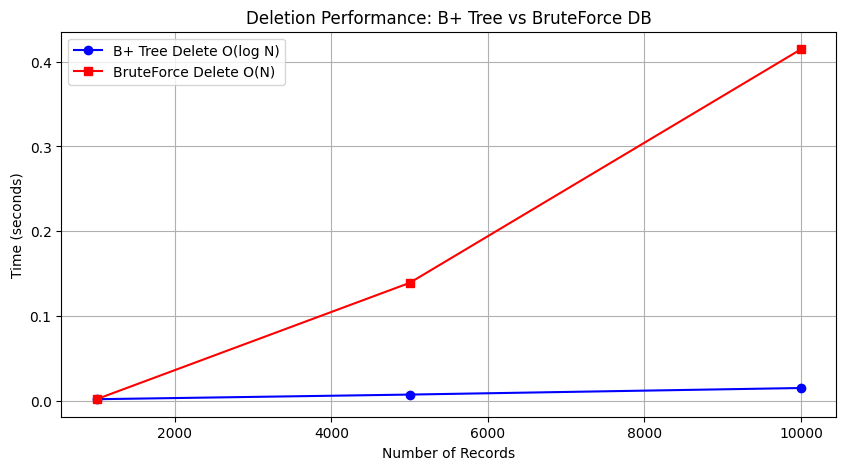

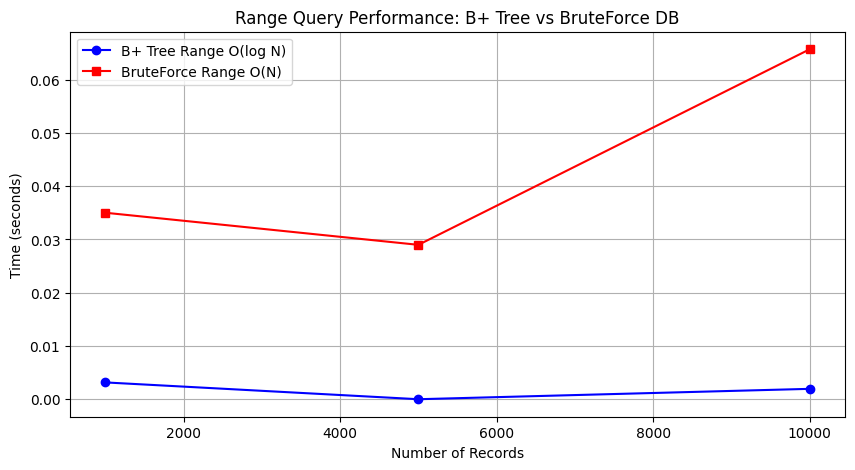

In [5]:
def benchmark_delete_and_range(sizes):
    bplus_del_times, brute_del_times = [], []
    bplus_range_times, brute_range_times = [], []
    
    for size in sizes:
        bpt = BPlusTree(order=4)
        bf = BruteForceDB()
        
        keys = random.sample(range(1, size * 10), size)
        action_keys = random.sample(keys, size // 10) # 10% of keys
        
        # Pre-load the databases
        for key in keys:
            bpt.insert(key, f"Val_{key}")
            bf.insert(key, f"Val_{key}")
            
        # --- THE FIX: RUN RANGE QUERIES 100 TIMES ---
        start_range = min(keys) + 100
        end_range = start_range + 500
        
        start = time.time()
        for _ in range(100):  # <--- Forces B+ Tree to work harder
            bpt.range_query(start_range, end_range)
        bplus_range_times.append(time.time() - start)
        
        start = time.time()
        for _ in range(100):  # <--- Forces BruteForce to scan 100 times
            bf.range_query(start_range, end_range)
        brute_range_times.append(time.time() - start)

        # --- Benchmark Deletions ---
        start = time.time()
        for key in action_keys:
            bpt.delete(key)
        bplus_del_times.append(time.time() - start)
        
        start = time.time()
        for key in action_keys:
            bf.delete(key)
        brute_del_times.append(time.time() - start)
        
    return bplus_del_times, brute_del_times, bplus_range_times, brute_range_times

# Run the benchmarks
dataset_sizes = [1000, 5000, 10000] 
b_del, br_del, b_range, br_range = benchmark_delete_and_range(dataset_sizes)

# Plot Deletion Results
plt.figure(figsize=(10, 5))
plt.plot(dataset_sizes, b_del, marker='o', label='B+ Tree Delete O(log N)', color='blue')
plt.plot(dataset_sizes, br_del, marker='s', label='BruteForce Delete O(N)', color='red')
plt.title('Deletion Performance: B+ Tree vs BruteForce DB')
plt.xlabel('Number of Records')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Range Query Results
plt.figure(figsize=(10, 5))
plt.plot(dataset_sizes, b_range, marker='o', label='B+ Tree Range O(log N)', color='blue')
plt.plot(dataset_sizes, br_range, marker='s', label='BruteForce Range O(N)', color='red')
plt.title('Range Query Performance: B+ Tree vs BruteForce DB')
plt.xlabel('Number of Records')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

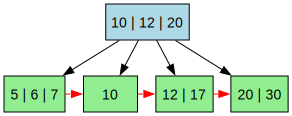

In [6]:
import importlib
import database.bplustree
importlib.reload(database.bplustree) # Force Jupyter to see the new code
from database.bplustree import BPlusTree

# Create a small, fresh tree just for the picture
visual_tree = BPlusTree(order=4)
keys_to_insert = [10, 20, 5, 6, 12, 30, 7, 17]

for key in keys_to_insert:
    visual_tree.insert(key, f"Val_{key}")

# Generate and display the graph!
tree_graph = visual_tree.visualize_tree()
tree_graph